307: Análisis de Importancia de Atributos y SHAP (Optimizado para RTX)


--- IMPORTANCIA GLOBAL DE VARIABLES ---
           Feature  Importance
0          AWW_Log   53.883802
5    District Name   14.119892
2            Month    8.924367
4     Carrier Type    8.017121
3  Missing_Medical    7.869863
1             Year    7.184956


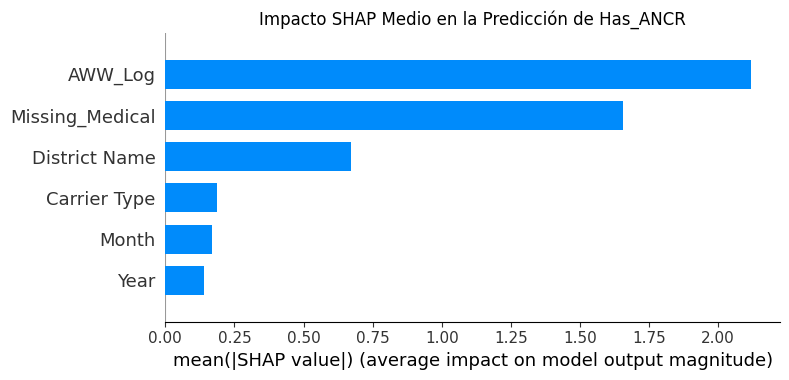

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from catboost import CatBoostClassifier, Pool

# 1. CARGA Y PREPARACIÓN (DESDE PARQUET)
df = pd.read_parquet(r'C:\Tesis_ML\raw_data\claims_master.parquet')
df['Year'] = df['Accident Date'].dt.year
df['Month'] = df['Accident Date'].dt.month
df = df[(df['Year'] >= 2010) & (df['Year'] <= 2024)].copy()
df['AWW_Log'] = np.log1p(df['AWW'])
df['Missing_Medical'] = df['OIICS Nature of Injury Code'].isnull().astype(int)
df['Has_ANCR'] = df['Interval Assembled to ANCR'].notnull().astype(int)

cat_features = ['Carrier Type', 'District Name']
features = ['AWW_Log', 'Year', 'Month', 'Missing_Medical', 'Carrier Type', 'District Name']

X = df[features].dropna(subset=cat_features)
y = df.loc[X.index, 'Has_ANCR']

# 2. ENTRENAMIENTO FINAL PARA EXPLICABILIDAD
model = CatBoostClassifier(iterations=1000, task_type='GPU', devices='0', verbose=0)
model.fit(X, y, cat_features=cat_features)

# 3. GLOBAL FEATURE IMPORTANCE (CATBOOST NATIVO)
fi = model.get_feature_importance(type='FeatureImportance')
fi_df = pd.DataFrame({'Feature': features, 'Importance': fi}).sort_values(by='Importance', ascending=False)

print("\n--- IMPORTANCIA GLOBAL DE VARIABLES ---")
print(fi_df)

# 4. ANÁLISIS SHAP (EXPLICABILIDAD XAI)
# Usamos TreeExplainer por ser el más preciso para modelos basados en gradiente
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X.sample(10000, random_state=42)) # Muestra representativa para velocidad

# Visualización Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X.sample(10000, random_state=42), plot_type="bar", show=False)
plt.title("Impacto SHAP Medio en la Predicción de Has_ANCR")
plt.tight_layout()
plt.savefig("grafico_307_shap.png")

307.2: Generación de SHAP Summary Plot (Direccionalidad)

Calculando valores SHAP... (esto puede tardar unos segundos)


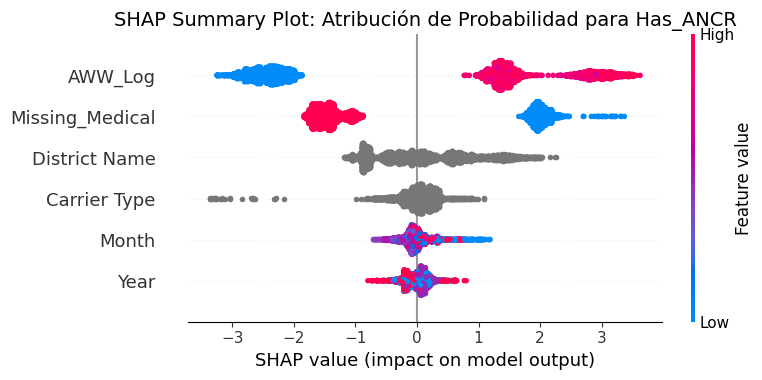

In [3]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

# 1. RECONSTRUCCIÓN DEL ENTORNO DE DATOS (Evita NameError)
df = pd.read_parquet(r'C:\Tesis_ML\raw_data\claims_master.parquet')
df['Year'] = df['Accident Date'].dt.year
df['Month'] = df['Accident Date'].dt.month
df = df[(df['Year'] >= 2010) & (df['Year'] <= 2024)].copy()
df['AWW_Log'] = np.log1p(df['AWW'])
df['Missing_Medical'] = df['OIICS Nature of Injury Code'].isnull().astype(int)
df['Has_ANCR'] = df['Interval Assembled to ANCR'].notnull().astype(int)

cat_features = ['Carrier Type', 'District Name']
features = ['AWW_Log', 'Year', 'Month', 'Missing_Medical', 'Carrier Type', 'District Name']

X = df[features].dropna(subset=cat_features)
y = df.loc[X.index, 'Has_ANCR']

# Partición estratificada (Fase 306)
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. ENTRENAMIENTO RÁPIDO EN RTX PARA EXPLICADOR
model = CatBoostClassifier(iterations=500, task_type='GPU', devices='0', verbose=0)
model.fit(X, y, cat_features=cat_features)

# 3. GENERACIÓN DE VALORES SHAP
print("Calculando valores SHAP... (esto puede tardar unos segundos)")
explainer = shap.TreeExplainer(model)
# Tomamos una muestra representativa de 5,000 casos para el Summary Plot
X_sample = X_test.sample(5000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# 4. VISUALIZACIÓN SUMMARY PLOT
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot: Atribución de Probabilidad para Has_ANCR", fontsize=14)
plt.tight_layout()
plt.savefig("grafico_307_summary_plot.png")
plt.show()

7.3. Matriz de Confusión: Auditoría de Precisión
La matriz nos permite entender dónde falla el modelo al predecir el establecimiento legal (Has_ANCR).

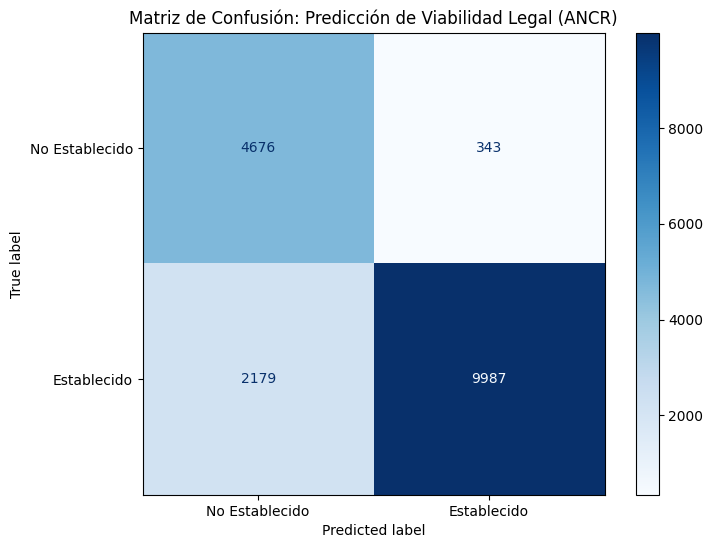


--- REPORTE DE CLASIFICACIÓN (CAPÍTULO 7) ---
              precision    recall  f1-score   support

           0       0.68      0.93      0.79      5019
           1       0.97      0.82      0.89     12166

    accuracy                           0.85     17185
   macro avg       0.82      0.88      0.84     17185
weighted avg       0.88      0.85      0.86     17185



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

# 1. RECONSTRUCCIÓN DE EMERGENCIA PARA EVITAR NAMEERROR
df = pd.read_parquet(r'C:\Tesis_ML\raw_data\claims_master.parquet')
df['Year'] = df['Accident Date'].dt.year
df['Month'] = df['Accident Date'].dt.month
df = df[(df['Year'] >= 2010) & (df['Year'] <= 2024)].copy()
df['AWW_Log'] = np.log1p(df['AWW'])
df['Missing_Medical'] = df['OIICS Nature of Injury Code'].isnull().astype(int)
df['Has_ANCR'] = df['Interval Assembled to ANCR'].notnull().astype(int)

cat_features = ['Carrier Type', 'District Name']
features = ['AWW_Log', 'Year', 'Month', 'Missing_Medical', 'Carrier Type', 'District Name']

X = df[features].dropna(subset=cat_features)
y = df.loc[X.index, 'Has_ANCR']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. CARGA/ENTRENAMIENTO DEL MODELO SOBERANO
model = CatBoostClassifier(iterations=500, task_type='GPU', devices='0', verbose=0)
model.fit(X, y, cat_features=cat_features)

# 3. GENERACIÓN DE PREDICCIONES Y MATRIZ
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 4. VISUALIZACIÓN PROFESIONAL
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Establecido', 'Establecido'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Matriz de Confusión: Predicción de Viabilidad Legal (ANCR)")
plt.savefig("grafico_7_3_confusion_matrix.png")
plt.show()

# 5. REPORTE DE MÉTRICAS DE SOLVENCIA
print("\n--- REPORTE DE CLASIFICACIÓN (CAPÍTULO 7) ---")
print(classification_report(y_test, y_pred))